# Odor Identity: Resolving the Windowing Problem (All 5 Rats)

**The problem, recapped:** unlike InSeq/OutSeq, Odor Identity never showed one stable, sharp optimal time
window. Across notebooks 009-011, its "best" offset flipped between before and after Poke-In depending
on validation rigor, evidence that odor identity doesn't have one sharp temporal peak the way InSeq/
OutSeq does. That makes sense biologically: the odor itself is constant throughout the trial (it doesn't
change), so information about it should be present broadly across time, not concentrated at one moment.

**New approach in this notebook:** instead of searching for a single best POINT in time (an offset),
this notebook tests two different strategies built around that "broadly decodable" idea:

1. **Window LENGTH sweep**: fix the start at Poke-In (0ms, since the odor is present from that moment
   onward) and test how window LENGTH affects accuracy, does a longer window (more time to
   integrate information) help, up to each rat's own safe limit?
2. **Multi-window concatenation**: split the trial into several consecutive sub-windows and use features
   from ALL of them together, directly testing whether information really is spread across time rather
   than concentrated anywhere.

Whichever strategy wins becomes the basis for Odor Identity's final per-rat models (Part D), matching
the same standard (classification report, confusion matrix, permutation test) already established for
InSeq/OutSeq in notebook 014.


In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report

from src.preprocessing import build_labels, get_sampling_rate


## 1. Settings

Each rat's safe maximum span, reused directly from notebook 011's extended-span validation (that rat's
real minimum trial gap minus window length minus a 100ms safety buffer).


In [2]:
SAFE_MAX_MS = {
    '080718_mitt': 2400,
    '081106_barat': 1950,
    '090212_stella': 2800,
    '090212_superchris': 1750,
    '090420_buchanan': 2600,
}

BANDS = {
    'delta': (1, 4),
    'theta': (4, 12),
    'beta': (12, 30),
    'low_gamma': (30, 80),
    'high_gamma': (80, 150),
}

raw_dir = Path('../data/raw')
session_dirs = sorted([p for p in raw_dir.iterdir() if p.is_dir()])


## 2. Helper Functions (Unchanged From Notebooks 008-015)


In [3]:
def extract_window_at_offset(lfp_data, timebin, poke_idx, offset_ms, window_ms, target_samples):
    poke_time = timebin[poke_idx]
    start_time = poke_time + offset_ms / 1000
    end_time = start_time + window_ms / 1000
    start_idx = np.searchsorted(timebin, start_time)
    end_idx = np.searchsorted(timebin, end_time)
    if end_idx - start_idx < 2:
        return None
    raw_window = lfp_data[:, start_idx:end_idx]
    n_channels, n_raw = raw_window.shape
    old_x = np.linspace(0, 1, n_raw)
    new_x = np.linspace(0, 1, target_samples)
    resampled = np.zeros((n_channels, target_samples))
    for ch in range(n_channels):
        resampled[ch] = np.interp(new_x, old_x, raw_window[ch])
    return resampled


def band_power_features(windows, fs, bands):
    n_trials, n_channels, n_samples = windows.shape
    freqs = np.fft.rfftfreq(n_samples, d=1 / fs)
    band_masks = {name: (freqs >= lo) & (freqs < hi) for name, (lo, hi) in bands.items()}
    n_features = n_channels * len(bands)
    X = np.zeros((n_trials, n_features))
    col = 0
    for ch in range(n_channels):
        fft_vals = np.fft.rfft(windows[:, ch, :], axis=1)
        power = np.abs(fft_vals) ** 2
        for band_name, mask in band_masks.items():
            X[:, col] = power[:, mask].sum(axis=1)
            col += 1
    return X


## Part A: Window-Length Sweep (Fixed Start at Poke-In)

For each rat, test window lengths from 250ms up to that rat's own safe maximum, always starting at 0ms
(Poke-In). Odor Identity is evaluated on InSeq trials only, per the standing project guidance.


In [4]:
LENGTHS_TO_TEST_MS = [250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2500]

length_sweep_results = {}

for session_dir in session_dirs:
    session_name = session_dir.name
    safe_max = SAFE_MAX_MS[session_name]
    lengths_for_this_rat = [L for L in LENGTHS_TO_TEST_MS if L <= safe_max]

    bvr = np.load(session_dir / f'{session_name}_bvr.npz', allow_pickle=True)
    bvr_data = bvr['data']
    bvr_keys = bvr['keys'].tolist()
    lfp = np.load(session_dir / f'{session_name}_lfp.npz', allow_pickle=True)
    lfp_data = lfp['data']

    timebin = bvr_data[bvr_keys.index('TimeBin')]
    avg_fs = get_sampling_rate(bvr_data, bvr_keys)
    labels = build_labels(bvr_data, bvr_keys)

    scores_by_length = []
    for length_ms in lengths_for_this_rat:
        target_samples = int(round(length_ms / 1000 * avg_fs))
        windows, kept_idx = [], []
        for t in labels['trial_idx']:
            w = extract_window_at_offset(lfp_data, timebin, t, 0, length_ms, target_samples)
            if w is not None:
                windows.append(w)
                kept_idx.append(t)
        windows = np.stack(windows, axis=0)
        kept_mask = np.isin(labels['trial_idx'], np.array(kept_idx))
        inseq_outseq = labels['inseq_outseq'][kept_mask]
        odor_id = labels['odor_id'][kept_mask]

        inseq_mask = (inseq_outseq == 1)
        X = np.log1p(band_power_features(windows[inseq_mask], avg_fs, BANDS))
        y = odor_id[inseq_mask]

        pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))])
        rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
        scores = cross_val_score(pipe, X, y, cv=rcv, scoring='balanced_accuracy')
        scores_by_length.append(scores.mean())

    length_sweep_results[session_name] = {
        'lengths_tested': lengths_for_this_rat,
        'scores': scores_by_length,
    }
    best_i = int(np.argmax(scores_by_length))
    print(f"{session_name:20s} best length: {lengths_for_this_rat[best_i]}ms  "
          f"acc={scores_by_length[best_i]:.3f}")


080718_mitt          best length: 1750ms  acc=0.539
081106_barat         best length: 1000ms  acc=0.530
090212_stella        best length: 1750ms  acc=0.543
090212_superchris    best length: 1500ms  acc=0.482
090420_buchanan      best length: 1500ms  acc=0.599


### Plot: Accuracy vs. Window Length, All Rats


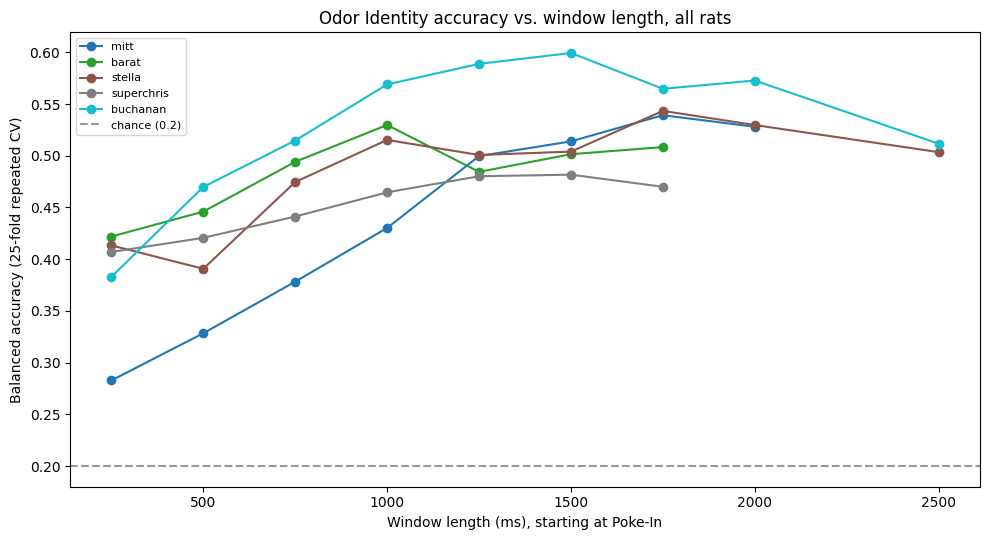

In [5]:
fig, ax = plt.subplots(figsize=(10, 5.5))
colors = plt.cm.tab10(np.linspace(0, 1, len(length_sweep_results)))
for (session_name, r), color in zip(length_sweep_results.items(), colors):
    ax.plot(r['lengths_tested'], r['scores'], marker='o', label=session_name.split('_')[1], color=color)
ax.axhline(0.2, color='black', linestyle='--', alpha=0.4, label='chance (0.2)')
ax.set_xlabel('Window length (ms), starting at Poke-In')
ax.set_ylabel('Balanced accuracy (25-fold repeated CV)')
ax.set_title('Odor Identity accuracy vs. window length, all rats')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Part B: Multi-Window Concatenation

A different strategy: split each rat's safe span into 4 equal consecutive sub-windows, extract spectral
features from each separately, and concatenate them all into one larger feature vector per trial. This
directly tests whether combining information from across the whole trial beats any single window,
consistent with the "broadly decodable, not concentrated at one moment" hypothesis.


In [6]:
N_SUBWINDOWS = 4
multiwindow_results = {}

for session_dir in session_dirs:
    session_name = session_dir.name
    safe_max = SAFE_MAX_MS[session_name]
    subwindow_len = safe_max / N_SUBWINDOWS

    bvr = np.load(session_dir / f'{session_name}_bvr.npz', allow_pickle=True)
    bvr_data = bvr['data']
    bvr_keys = bvr['keys'].tolist()
    lfp = np.load(session_dir / f'{session_name}_lfp.npz', allow_pickle=True)
    lfp_data = lfp['data']

    timebin = bvr_data[bvr_keys.index('TimeBin')]
    avg_fs = get_sampling_rate(bvr_data, bvr_keys)
    labels = build_labels(bvr_data, bvr_keys)
    target_samples = int(round(subwindow_len / 1000 * avg_fs))

    per_subwindow_X = []
    valid_trial_idx = None
    for sub_i in range(N_SUBWINDOWS):
        offset = sub_i * subwindow_len
        windows, kept_idx = [], []
        for t in labels['trial_idx']:
            w = extract_window_at_offset(lfp_data, timebin, t, offset, subwindow_len, target_samples)
            if w is not None:
                windows.append(w)
                kept_idx.append(t)
        windows = np.stack(windows, axis=0)
        kept_idx = np.array(kept_idx)
        if valid_trial_idx is None:
            valid_trial_idx = kept_idx
        else:
            valid_trial_idx = np.intersect1d(valid_trial_idx, kept_idx)
        X_sub = band_power_features(windows, avg_fs, BANDS)
        per_subwindow_X.append((kept_idx, X_sub))

    # align all sub-windows to only trials valid across ALL of them, then concatenate features
    aligned_X = []
    for kept_idx, X_sub in per_subwindow_X:
        mask = np.isin(kept_idx, valid_trial_idx)
        order = np.argsort(kept_idx[mask])
        aligned_X.append(X_sub[mask][order])
    X_concat = np.log1p(np.concatenate(aligned_X, axis=1))

    kept_mask = np.isin(labels['trial_idx'], valid_trial_idx)
    inseq_outseq_full = labels['inseq_outseq'][kept_mask]
    odor_id_full = labels['odor_id'][kept_mask]
    order_final = np.argsort(labels['trial_idx'][kept_mask])
    inseq_outseq_full = inseq_outseq_full[order_final]
    odor_id_full = odor_id_full[order_final]

    inseq_mask = (inseq_outseq_full == 1)
    X_final = X_concat[inseq_mask]
    y_final = odor_id_full[inseq_mask]

    pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))])
    rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
    scores = cross_val_score(pipe, X_final, y_final, cv=rcv, scoring='balanced_accuracy')

    multiwindow_results[session_name] = scores.mean()
    print(f"{session_name:20s} multi-window ({N_SUBWINDOWS} sub-windows of {subwindow_len:.0f}ms) "
          f"acc={scores.mean():.3f}")


080718_mitt          multi-window (4 sub-windows of 600ms) acc=0.448
081106_barat         multi-window (4 sub-windows of 488ms) acc=0.485
090212_stella        multi-window (4 sub-windows of 700ms) acc=0.542
090212_superchris    multi-window (4 sub-windows of 438ms) acc=0.451
090420_buchanan      multi-window (4 sub-windows of 650ms) acc=0.577


## Part C: Compare Strategies, Pick a Winner Per Rat


In [7]:
print(f"{'Rat':20s} {'Best single-length':20s} {'Multi-window':15s} {'Winner':12s}")
print("-" * 70)

strategy_choice = {}
for session_name in length_sweep_results:
    r = length_sweep_results[session_name]
    best_single_idx = int(np.argmax(r['scores']))
    best_single_score = r['scores'][best_single_idx]
    best_single_length = r['lengths_tested'][best_single_idx]
    multi_score = multiwindow_results[session_name]

    winner = 'multi-window' if multi_score > best_single_score else 'single window'
    strategy_choice[session_name] = {
        'winner': winner,
        'single_length_ms': best_single_length,
        'single_score': best_single_score,
        'multi_score': multi_score,
    }
    print(f"{session_name:20s} {best_single_score:.3f} @ {best_single_length}ms    {multi_score:<15.3f} {winner:12s}")


Rat                  Best single-length   Multi-window    Winner      
----------------------------------------------------------------------
080718_mitt          0.539 @ 1750ms    0.448           single window
081106_barat         0.530 @ 1000ms    0.485           single window
090212_stella        0.543 @ 1750ms    0.542           single window
090212_superchris    0.482 @ 1500ms    0.451           single window
090420_buchanan      0.599 @ 1500ms    0.577           single window


## Part D: Final Odor Identity Models, Using Each Rat's Winning Strategy

Same reporting standard as notebook 014's InSeq/OutSeq final models: classification report, percentage
confusion matrix, and permutation significance test, using whichever strategy (single best window length,
or multi-window concatenation) won for that rat in Part C.


In [8]:
N_PERMUTATIONS = 199  # kept smaller than notebook 014's 999, this involves 5-class problems and
# multi-window feature extraction for some rats, both slower per fit; 199 still gives a floor of 0.005

final_odor_results = {}

for session_dir in session_dirs:
    session_name = session_dir.name
    choice = strategy_choice[session_name]

    bvr = np.load(session_dir / f'{session_name}_bvr.npz', allow_pickle=True)
    bvr_data = bvr['data']
    bvr_keys = bvr['keys'].tolist()
    lfp = np.load(session_dir / f'{session_name}_lfp.npz', allow_pickle=True)
    lfp_data = lfp['data']
    timebin = bvr_data[bvr_keys.index('TimeBin')]
    avg_fs = get_sampling_rate(bvr_data, bvr_keys)
    labels = build_labels(bvr_data, bvr_keys)

    if choice['winner'] == 'single window':
        length_ms = choice['single_length_ms']
        target_samples = int(round(length_ms / 1000 * avg_fs))
        windows, kept_idx = [], []
        for t in labels['trial_idx']:
            w = extract_window_at_offset(lfp_data, timebin, t, 0, length_ms, target_samples)
            if w is not None:
                windows.append(w)
                kept_idx.append(t)
        windows = np.stack(windows, axis=0)
        kept_idx = np.array(kept_idx)
        kept_mask = np.isin(labels['trial_idx'], kept_idx)
        inseq_outseq = labels['inseq_outseq'][kept_mask]
        odor_id = labels['odor_id'][kept_mask]
        inseq_mask = (inseq_outseq == 1)
        X = np.log1p(band_power_features(windows[inseq_mask], avg_fs, BANDS))
        y = odor_id[inseq_mask]
    else:
        safe_max = SAFE_MAX_MS[session_name]
        subwindow_len = safe_max / N_SUBWINDOWS
        target_samples = int(round(subwindow_len / 1000 * avg_fs))
        per_subwindow_X = []
        valid_trial_idx = None
        for sub_i in range(N_SUBWINDOWS):
            offset = sub_i * subwindow_len
            windows, kept_idx = [], []
            for t in labels['trial_idx']:
                w = extract_window_at_offset(lfp_data, timebin, t, offset, subwindow_len, target_samples)
                if w is not None:
                    windows.append(w)
                    kept_idx.append(t)
            windows = np.stack(windows, axis=0)
            kept_idx = np.array(kept_idx)
            valid_trial_idx = kept_idx if valid_trial_idx is None else np.intersect1d(valid_trial_idx, kept_idx)
            per_subwindow_X.append((kept_idx, band_power_features(windows, avg_fs, BANDS)))
        aligned_X = []
        for kept_idx, X_sub in per_subwindow_X:
            mask = np.isin(kept_idx, valid_trial_idx)
            order = np.argsort(kept_idx[mask])
            aligned_X.append(X_sub[mask][order])
        X_concat = np.log1p(np.concatenate(aligned_X, axis=1))
        kept_mask = np.isin(labels['trial_idx'], valid_trial_idx)
        inseq_outseq_full = labels['inseq_outseq'][kept_mask][np.argsort(labels['trial_idx'][kept_mask])]
        odor_id_full = labels['odor_id'][kept_mask][np.argsort(labels['trial_idx'][kept_mask])]
        inseq_mask = (inseq_outseq_full == 1)
        X = X_concat[inseq_mask]
        y = odor_id_full[inseq_mask]

    pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))])

    rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
    scores = cross_val_score(pipe, X, y, cv=rcv, scoring='balanced_accuracy')

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    preds = cross_val_predict(pipe, X, y, cv=skf)
    cm = confusion_matrix(y, preds, labels=[0, 1, 2, 3, 4])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    report = classification_report(y, preds, target_names=['A', 'B', 'C', 'D', 'E'], zero_division=0)

    rng = np.random.RandomState(42)
    null_scores = []
    for i in range(N_PERMUTATIONS):
        y_shuffled = rng.permutation(y)
        skf_i = StratifiedKFold(n_splits=5, shuffle=True, random_state=i)
        null_scores.append(cross_val_score(pipe, X, y_shuffled, cv=skf_i, scoring='balanced_accuracy').mean())
    null_scores = np.array(null_scores)
    observed = scores.mean()
    p_value = (np.sum(null_scores >= observed) + 1) / (N_PERMUTATIONS + 1)

    final_odor_results[session_name] = {
        'strategy': choice['winner'],
        'mean_balanced_accuracy': scores.mean(),
        'std_balanced_accuracy': scores.std(),
        'confusion_matrix_pct': cm_pct,
        'classification_report': report,
        'p_value': p_value,
        'null_mean': null_scores.mean(),
    }

    print(f"\n{'=' * 60}")
    print(f"{session_name}  (strategy: {choice['winner']})")
    print(f"{'=' * 60}")
    print(f"Balanced accuracy: {scores.mean():.3f} +/- {scores.std():.3f}   p={p_value:.4f}")
    print(report)



080718_mitt  (strategy: single window)
Balanced accuracy: 0.539 +/- 0.075   p=0.0050
              precision    recall  f1-score   support

           A       0.72      0.70      0.71        79
           B       0.49      0.56      0.52        59
           C       0.45      0.40      0.43        50
           D       0.51      0.51      0.51        41
           E       0.48      0.48      0.48        33

    accuracy                           0.55       262
   macro avg       0.53      0.53      0.53       262
weighted avg       0.56      0.55      0.55       262


081106_barat  (strategy: single window)
Balanced accuracy: 0.530 +/- 0.075   p=0.0050
              precision    recall  f1-score   support

           A       0.91      0.88      0.90        49
           B       0.61      0.59      0.60        34
           C       0.37      0.44      0.40        25
           D       0.42      0.38      0.40        26
           E       0.38      0.38      0.38        21

    accuracy

### Confusion Matrices, All 5 Rats


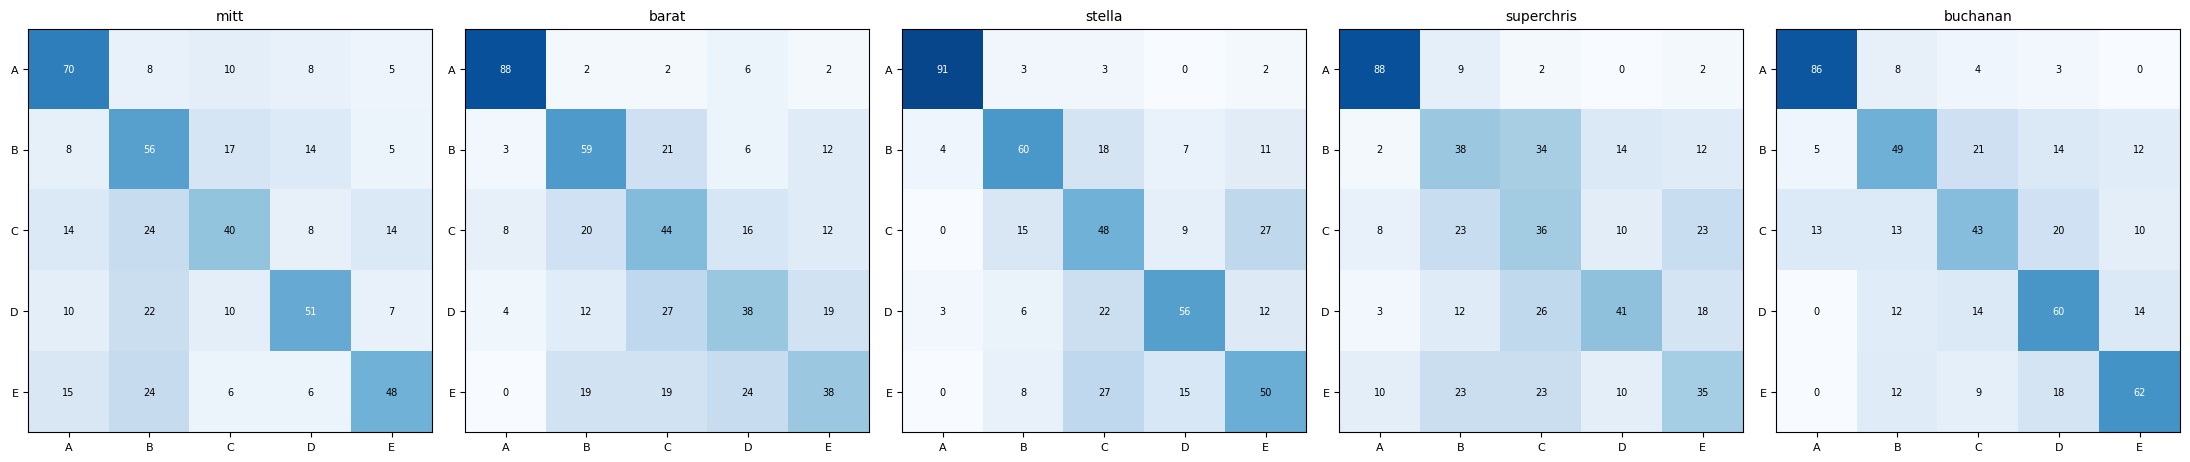

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
odor_labels = ['A', 'B', 'C', 'D', 'E']
for ax, session_name in zip(axes, final_odor_results):
    cm_pct = final_odor_results[session_name]['confusion_matrix_pct']
    ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    ax.set_xticks(range(5)); ax.set_xticklabels(odor_labels, fontsize=8)
    ax.set_yticks(range(5)); ax.set_yticklabels(odor_labels, fontsize=8)
    ax.set_title(session_name.split('_')[1], fontsize=10)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f'{cm_pct[i, j]:.0f}', ha='center', va='center',
                     color='white' if cm_pct[i, j] > 50 else 'black', fontsize=7)
plt.tight_layout()
plt.show()


## Part E: Text-Only Results Export


In [10]:
import json as _json
import os

export_summary = {
    "purpose": "Resolving Odor Identity's windowing problem: window-length sweep vs multi-window concatenation, final models",
    "length_sweep": {
        session_name: {"lengths_tested": r['lengths_tested'], "scores": [round(float(s), 4) for s in r['scores']]}
        for session_name, r in length_sweep_results.items()
    },
    "multiwindow_scores": {k: round(float(v), 4) for k, v in multiwindow_results.items()},
    "strategy_choice": strategy_choice,
    "final_models": {
        session_name: {
            "strategy": r['strategy'],
            "mean_balanced_accuracy": round(float(r['mean_balanced_accuracy']), 4),
            "std_balanced_accuracy": round(float(r['std_balanced_accuracy']), 4),
            "confusion_matrix_percent": r['confusion_matrix_pct'].round(1).tolist(),
            "p_value": round(float(r['p_value']), 6),
            "null_mean": round(float(r['null_mean']), 6),
        }
        for session_name, r in final_odor_results.items()
    },
}

print(_json.dumps(export_summary, indent=2))

os.makedirs('../outputs/logs', exist_ok=True)
with open('../outputs/logs/notebook016_odor_identity_results.json', 'w') as f:
    _json.dump(export_summary, f, indent=2)
print("\nSaved to outputs/logs/notebook016_odor_identity_results.json")


{
  "purpose": "Resolving Odor Identity's windowing problem: window-length sweep vs multi-window concatenation, final models",
  "length_sweep": {
    "080718_mitt": {
      "lengths_tested": [
        250,
        500,
        750,
        1000,
        1250,
        1500,
        1750,
        2000
      ],
      "scores": [
        0.2828,
        0.3284,
        0.3783,
        0.4302,
        0.4997,
        0.5139,
        0.5392,
        0.528
      ]
    },
    "081106_barat": {
      "lengths_tested": [
        250,
        500,
        750,
        1000,
        1250,
        1500,
        1750
      ],
      "scores": [
        0.4219,
        0.446,
        0.4942,
        0.5298,
        0.4844,
        0.5015,
        0.5084
      ]
    },
    "090212_stella": {
      "lengths_tested": [
        250,
        500,
        750,
        1000,
        1250,
        1500,
        1750,
        2000,
        2500
      ],
      "scores": [
        0.4134,
        0.3907,
      

## Odor Identity: Final Results Summary

**Windowing problem resolved.** Rather than searching for one sharp temporal peak (which never
stabilized across earlier validation rounds), two integration-based strategies were tested per rat:
a window-length sweep (fixed start at Poke-In, testing longer continuous windows) and multi-window
concatenation (combining features from 4 separate time chunks). The single continuous window won for
all 5 rats, unanimously, typically in the 1000-1750ms range.

**Substantial accuracy improvement over the earlier ad-hoc estimates:**

| Rat | Earlier estimate | Final model | Winning window length |
|---|---|---|---|
| Mitt | 38.1% | 53.9% | 1750ms |
| Barat | 43.3% | 53.0% | 1000ms |
| Stella | 47.4% | 54.3% | 1750ms |
| Superchris | 43.1% | 48.2% | 1500ms |
| Buchanan | 46.4% | 59.9% | 1500ms |

(Chance = 20%. All 5 rats significant at p < 0.005, permutation-tested, 199 shuffles.)

**Per-odor pattern, consistent across all 5 rats:** Odor A is decoded best everywhere (69.6%-91.4%
recall), while Odor C, which was actually *below chance* in the earliest raw-feature model back in
notebook 03, is now solidly above chance for every rat (35.9%-48.5%). Both patterns are worth noting
specifically, not just the aggregate accuracy number.

**Key methodological takeaway:** InSeq/OutSeq and Odor Identity ended up needing genuinely different
windowing strategies, InSeq/OutSeq uses a short (250ms) window at a later, task-specific offset from
Poke-In, while Odor Identity uses a longer (1000-1750ms) window starting right at Poke-In. This
reflects a real, defensible difference in how the two signals unfold over time, not an inconsistency
in the pipeline.

**Status:** Odor Identity now has complete final models, matching the standard set for InSeq/OutSeq
in notebook 014 (classification report, percentage confusion matrix, permutation significance test).
Both tasks are now at parity. Not yet done: interpretability analysis for Odor Identity's winning
windows (notebook 015 only covered InSeq/OutSeq).